In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
zip_path = r"C:\Users\rbaud\OneDrive\MDA 760\archive.zip"
extract_path = r"C:\Users\rbaud\OneDrive\MDA 760\amazon_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("completed")

completed


In [3]:
file_path = r"C:\Users\rbaud\OneDrive\MDA 760\amazon_data\amazon_sales_dataset.csv"

df = pd.read_csv(file_path)

df.head()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


In [4]:
df['order_date'] = pd.to_datetime(df['order_date'])

df.isnull().sum()

order_id            0
order_date          0
product_id          0
product_category    0
price               0
discount_percent    0
quantity_sold       0
customer_region     0
payment_method      0
rating              0
review_count        0
discounted_price    0
total_revenue       0
dtype: int64

In [5]:
df['discount_amount'] = df['price'] - df['discounted_price']
df['revenue_per_unit'] = df['total_revenue'] / df['quantity_sold']
df['month'] = df['order_date'].dt.month

In [6]:
df.describe()

,order_id,order_date,product_id,price,discount_percent,quantity_sold,rating,review_count,discounted_price,total_revenue,discount_amount,revenue_per_unit,month
count,50000.000000,50000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.0000
mean,25000.500000,2022-12-31 10:47:16.800000256,2986.848740,252.507260,13.340700,2.999400,2.996316,249.329280,218.886566,657.331475,33.620694,218.886566,6.5044
min,1.000000,2022-01-01 00:00:00,1000.000000,5.010000,0.000000,1.000000,1.000000,0.000000,3.530000,3.840000,0.000000,3.530000,1.0000
25%,12500.750000,2022-07-02 00:00:00,1983.000000,127.840000,5.000000,2.000000,2.000000,125.000000,109.680000,240.320000,6.290000,109.680000,4.0000
50%,25000.500000,2023-01-02 00:00:00,2983.000000,252.970000,10.000000,3.000000,3.000000,250.000000,215.805000,505.410000,22.580000,215.805000,7.0000
75%,37500.250000,2023-07-02 00:00:00,3989.000000,376.335000,20.000000,4.000000,4.000000,374.000000,322.702500,968.970000,50.240000,322.702500,9.0000
max,50000.000000,2023-12-31 00:00:00,4999.000000,499.990000,30.000000,5.000000,5.000000,499.000000,499.910000,2499.550000,150.000000,499.910000,12.0000
std,14433.901067,NaN,1156.374535,143.025544,9.850694,1.415401,1.154295,144.251981,127.317681,526.223968,34.169307,127.317681,3.4360


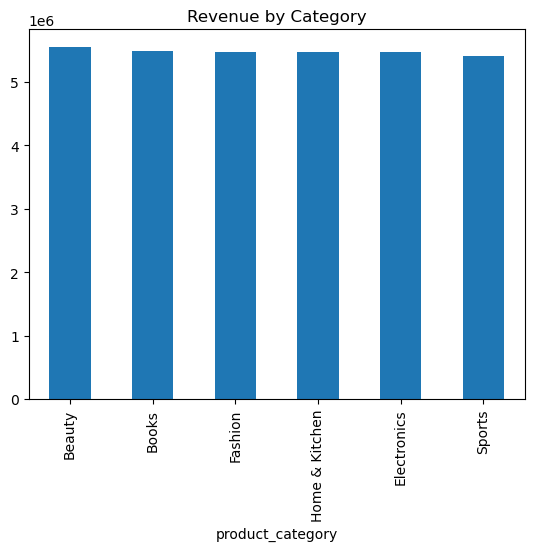

In [7]:
category_sales = df.groupby('product_category')['total_revenue'].sum().sort_values(ascending=False)

category_sales.head(10).plot(kind='bar')
plt.title("Revenue by Category")
plt.show()

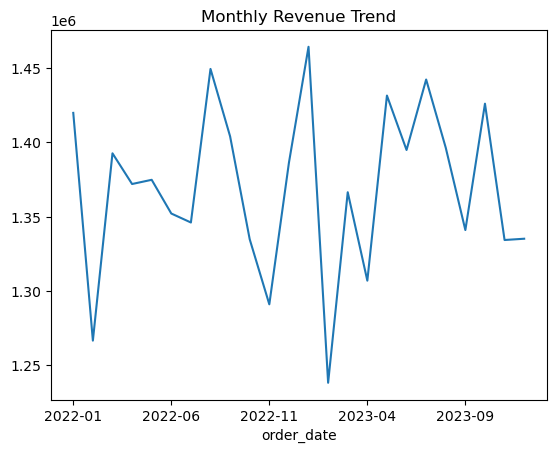

In [8]:
monthly_sales = df.groupby(df['order_date'].dt.to_period('M'))['total_revenue'].sum()

monthly_sales.index = monthly_sales.index.astype(str)

monthly_sales.plot()
plt.title("Monthly Revenue Trend")
plt.show()

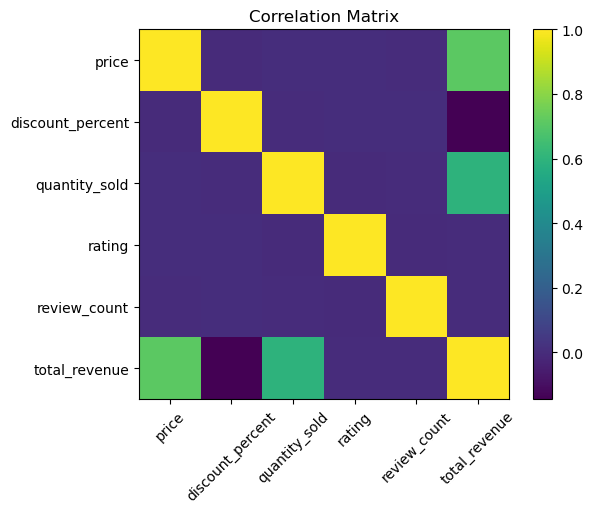

In [9]:
corr = df[['price', 'discount_percent', 'quantity_sold', 'rating', 'review_count', 'total_revenue']].corr()

plt.imshow(corr)
plt.colorbar()
plt.title("Correlation Matrix")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.show()

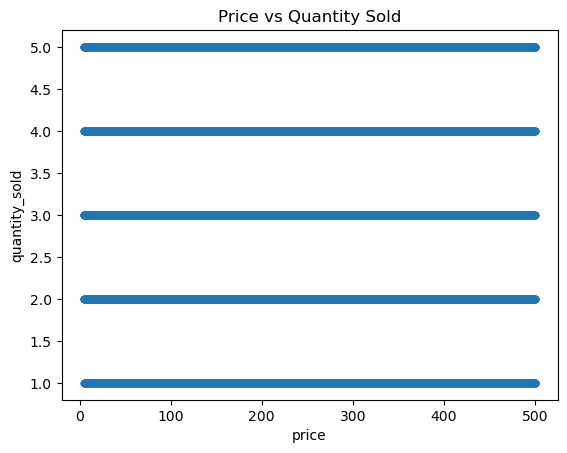

In [10]:
df.plot.scatter(x='price', y='quantity_sold')
plt.title("Price vs Quantity Sold")
plt.show()

In [11]:
elasticity_df = df[(df['price'] > 0) & (df['quantity_sold'] > 0)]

elasticity_df['log_price'] = np.log(elasticity_df['price'])
elasticity_df['log_quantity'] = np.log(elasticity_df['quantity_sold'])

elasticity_df[['log_price', 'log_quantity']].corr()

,log_price,log_quantity
log_price,1.000000,0.001609
log_quantity,0.001609,1.000000


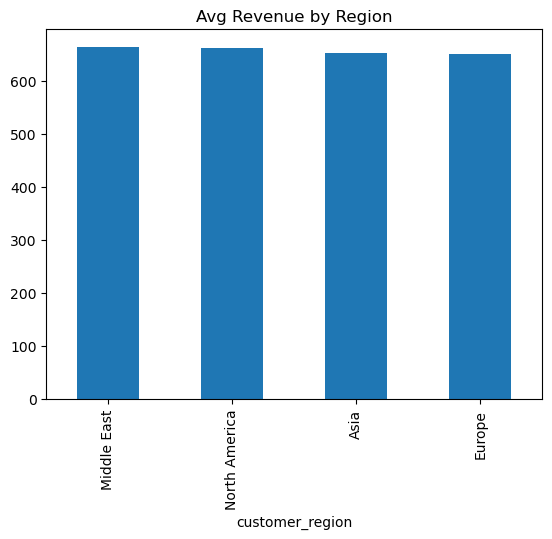

In [12]:
region_analysis = df.groupby('customer_region')['total_revenue'].mean().sort_values(ascending=False)

region_analysis.plot(kind='bar')
plt.title("Avg Revenue by Region")
plt.show()

In [13]:
X = df[['price', 'discount_percent', 'quantity_sold', 'rating', 'review_count']]
y = df['total_revenue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

model.score(X_test, y_test)

0.8755787714759635

In [14]:
coefficients = pd.Series(model.coef_, index=X.columns)
coefficients

price                 2.607449
discount_percent     -7.561297
quantity_sold       219.156054
rating                0.436359
review_count          0.006129
dtype: float64

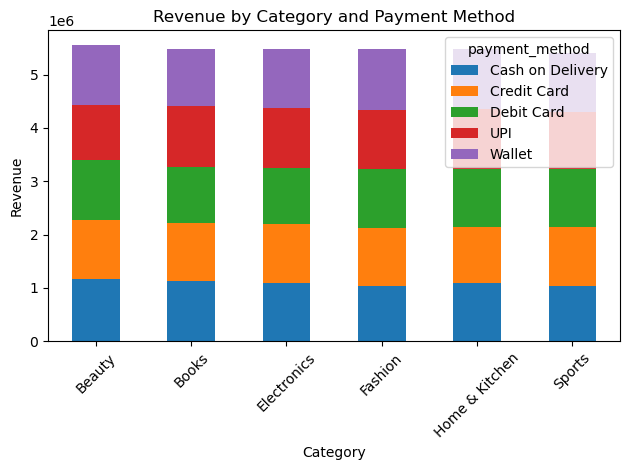

In [15]:
pivot = df.pivot_table(
    values='total_revenue',
    index='product_category',
    columns='payment_method',
    aggfunc='sum'
)

pivot.plot(kind='bar', stacked=True)

plt.title("Revenue by Category and Payment Method")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

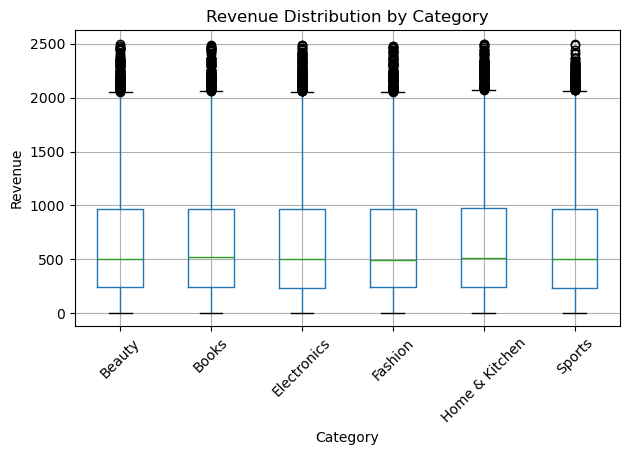

In [16]:
df.boxplot(column='total_revenue', by='product_category', rot=45)

plt.title("Revenue Distribution by Category")
plt.suptitle("")  
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

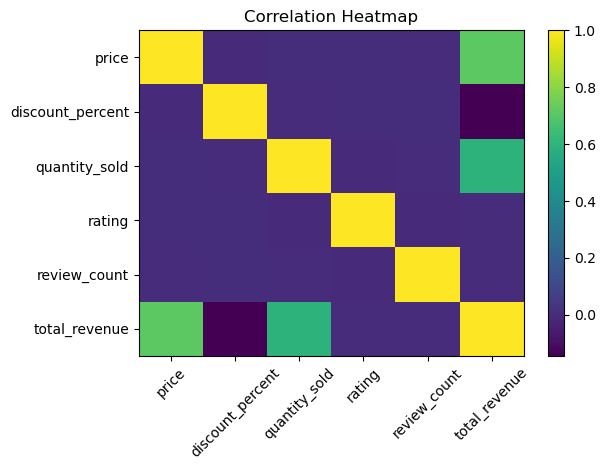

In [17]:
plt.imshow(corr, aspect='auto')

plt.colorbar()
plt.title("Correlation Heatmap")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.tight_layout()
plt.show()

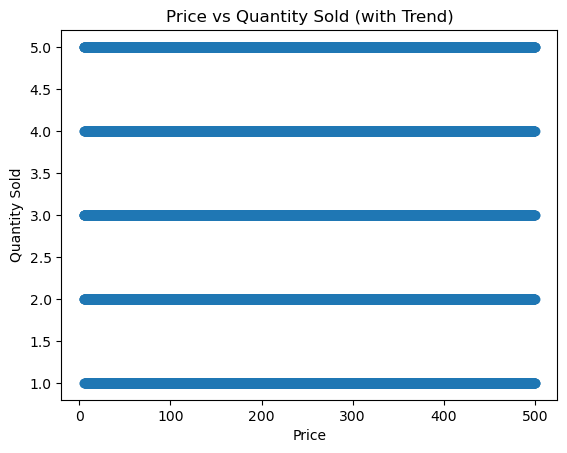

In [18]:
plt.scatter(df['price'], df['quantity_sold'], alpha=0.3)

z = np.polyfit(df['price'], df['quantity_sold'], 1)
p = np.poly1d(z)

plt.plot(df['price'], p(df['price']))

plt.title("Price vs Quantity Sold (with Trend)")
plt.xlabel("Price")
plt.ylabel("Quantity Sold")

plt.show()

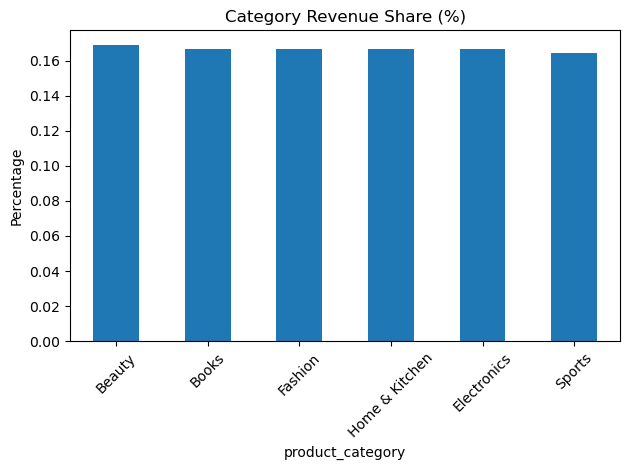

In [19]:
category_share = category_sales / category_sales.sum()

category_share.plot(kind='bar')

plt.title("Category Revenue Share (%)")
plt.ylabel("Percentage")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

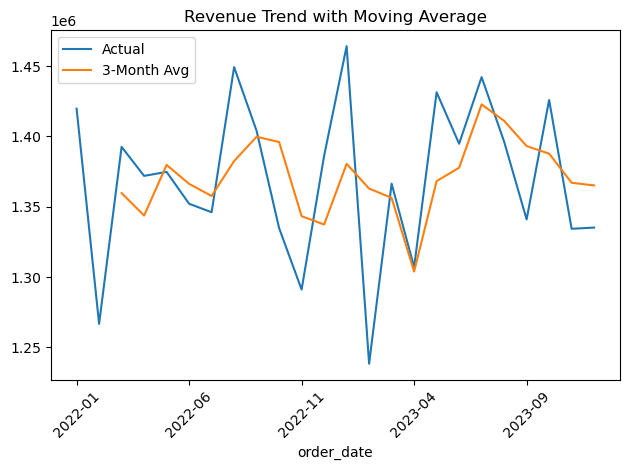

In [20]:
monthly_sales_rolling = monthly_sales.rolling(3).mean()

monthly_sales.plot(label='Actual')
monthly_sales_rolling.plot(label='3-Month Avg')

plt.title("Revenue Trend with Moving Average")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

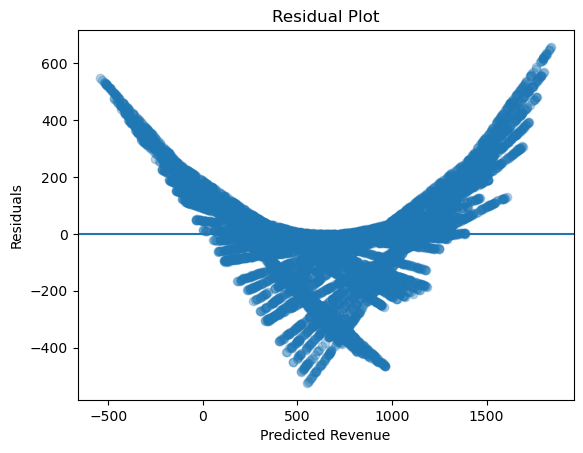

In [21]:
y_pred = model.predict(X_test)

residuals = y_test - y_pred

plt.scatter(y_pred, residuals, alpha=0.3)
plt.axhline(0)

plt.title("Residual Plot")
plt.xlabel("Predicted Revenue")
plt.ylabel("Residuals")

plt.show()

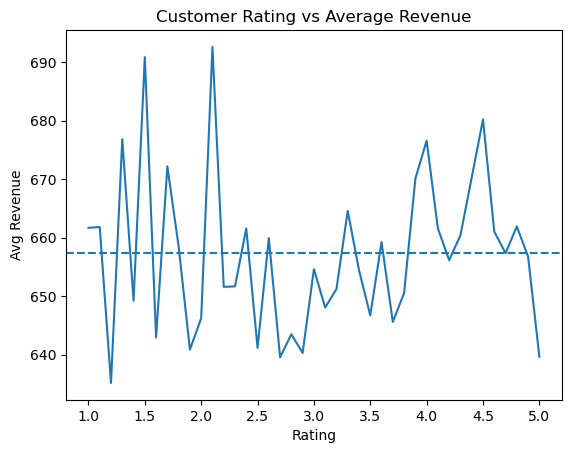

In [25]:
avg_revenue = df['total_revenue'].mean()

df.groupby('rating')['total_revenue'].mean().plot()

plt.axhline(avg_revenue, linestyle='--')

plt.title("Customer Rating vs Average Revenue")
plt.xlabel("Rating")
plt.ylabel("Avg Revenue")

plt.show()